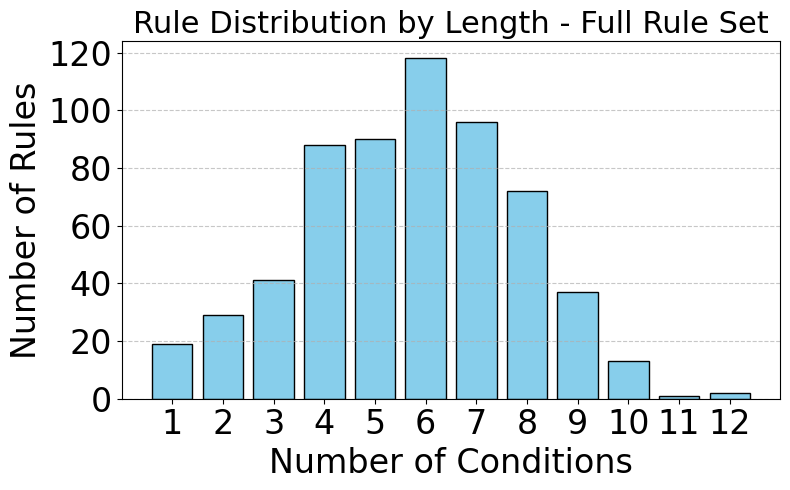

In [1]:
import matplotlib.pyplot as plt

# Get the Full Rule Set Distribution by Length

# Data
dimensions = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
rule_counts = [19, 29, 41, 88, 90, 118, 96, 72, 37, 13, 1, 2]

# Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(dimensions, rule_counts, color='skyblue', edgecolor='black')
plt.xlabel('Number of Conditions', fontsize=24)
plt.ylabel('Number of Rules', fontsize=24)
plt.title('Rule Distribution by Length - Full Rule Set', fontsize=22)
plt.xticks(dimensions, fontsize=24)
plt.yticks(fontsize=24)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

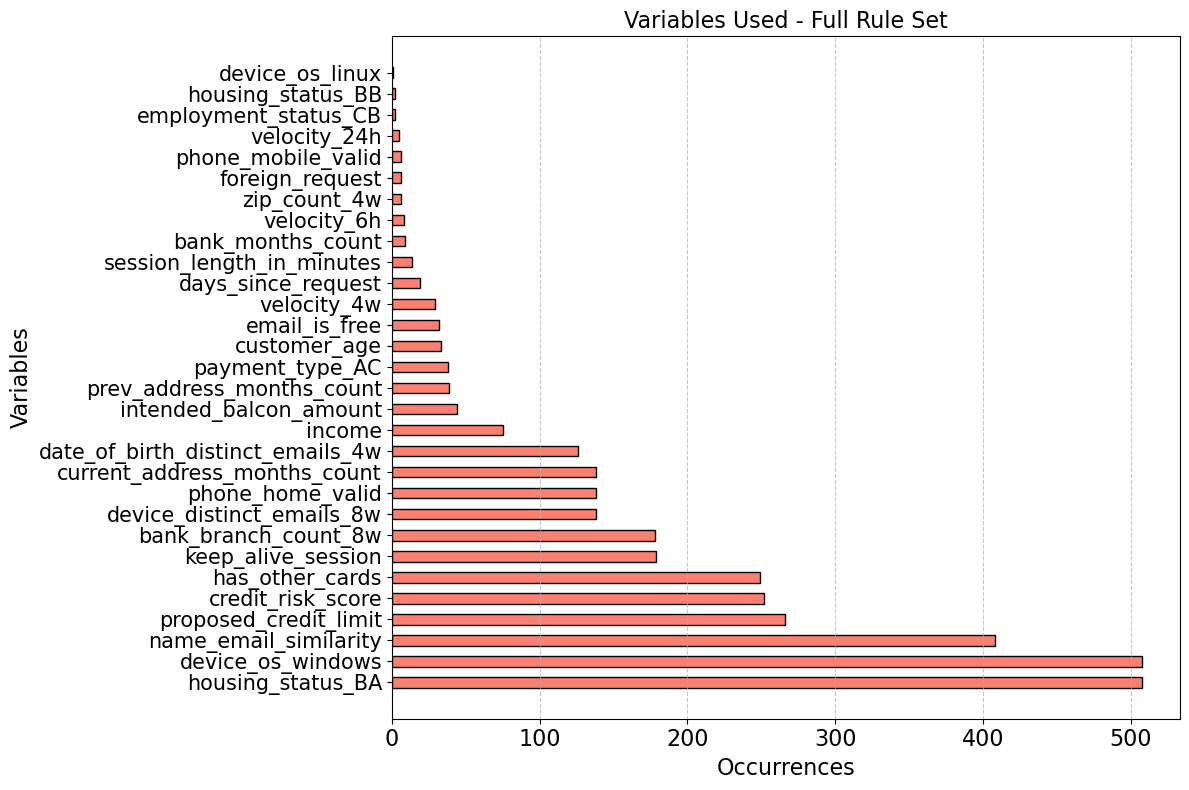

In [11]:
# Get the Full Rule Set Distribution by Variables Used

# Data
variables = [
    'housing_status_BA', 'device_os_windows', 'name_email_similarity', 
    'proposed_credit_limit', 'credit_risk_score', 'has_other_cards', 
    'keep_alive_session', 'bank_branch_count_8w', 'device_distinct_emails_8w',
    'phone_home_valid', 'current_address_months_count', 'date_of_birth_distinct_emails_4w',
    'income', 'intended_balcon_amount', 'prev_address_months_count',
    'payment_type_AC', 'customer_age', 'email_is_free', 'velocity_4w',
    'days_since_request', 'session_length_in_minutes', 'bank_months_count',
    'velocity_6h', 'zip_count_4w', 'foreign_request', 'phone_mobile_valid',
    'velocity_24h', 'employment_status_CB', 'housing_status_BB', 'device_os_linux'
]
occurrences = [
    508, 508, 408, 266, 252, 249, 179, 178, 138, 138, 138, 126, 
    75, 44, 39, 38, 33, 32, 29, 19, 14, 9, 8, 6, 6, 6, 5, 2, 2, 1
]

# Horizontal Bar Chart
plt.figure(figsize=(12, 8))
plt.barh(variables, occurrences, color='salmon', edgecolor='black', height=0.5)
plt.xlabel('Occurrences', fontsize=16)
plt.ylabel('Variables', fontsize=16)
plt.title('Variables Used - Full Rule Set', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Rule distribution by dimensions:
  3 dimensions: 3 rules
  4 dimensions: 4 rules
  5 dimensions: 6 rules
  6 dimensions: 12 rules
  7 dimensions: 13 rules
  8 dimensions: 4 rules
  9 dimensions: 5 rules
  10 dimensions: 2 rules

Variables used across all rules:
  device_os_windows: 43 occurrences
  name_email_similarity: 39 occurrences
  housing_status_BA: 37 occurrences
  has_other_cards: 31 occurrences
  proposed_credit_limit: 24 occurrences
  credit_risk_score: 21 occurrences
  keep_alive_session: 20 occurrences
  bank_branch_count_8w: 16 occurrences
  date_of_birth_distinct_emails_4w: 15 occurrences
  phone_home_valid: 15 occurrences
  current_address_months_count: 10 occurrences
  income: 7 occurrences
  device_distinct_emails_8w: 5 occurrences
  housing_status_BB: 5 occurrences
  housing_status_BC: 4 occurrences
  email_is_free: 3 occurrences
  device_os_linux: 3 occurrences
  device_os_macintosh: 3 occurrences
  prev_address_months_count: 2 occurrences
  housing_status_BD: 2 occ

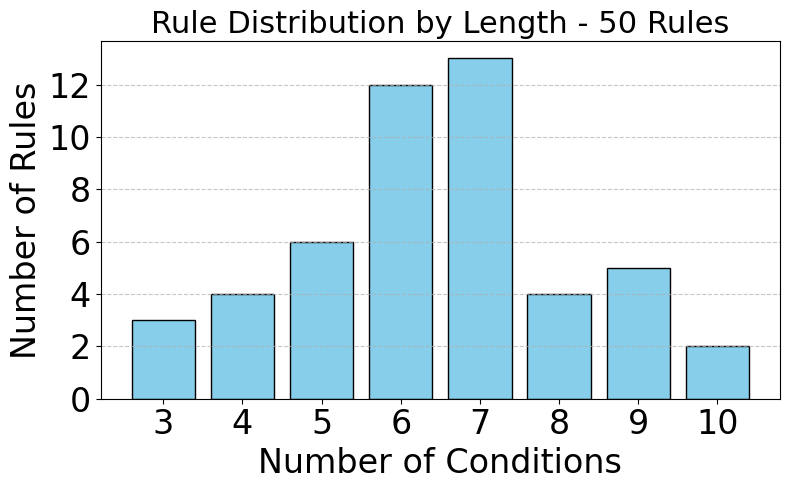

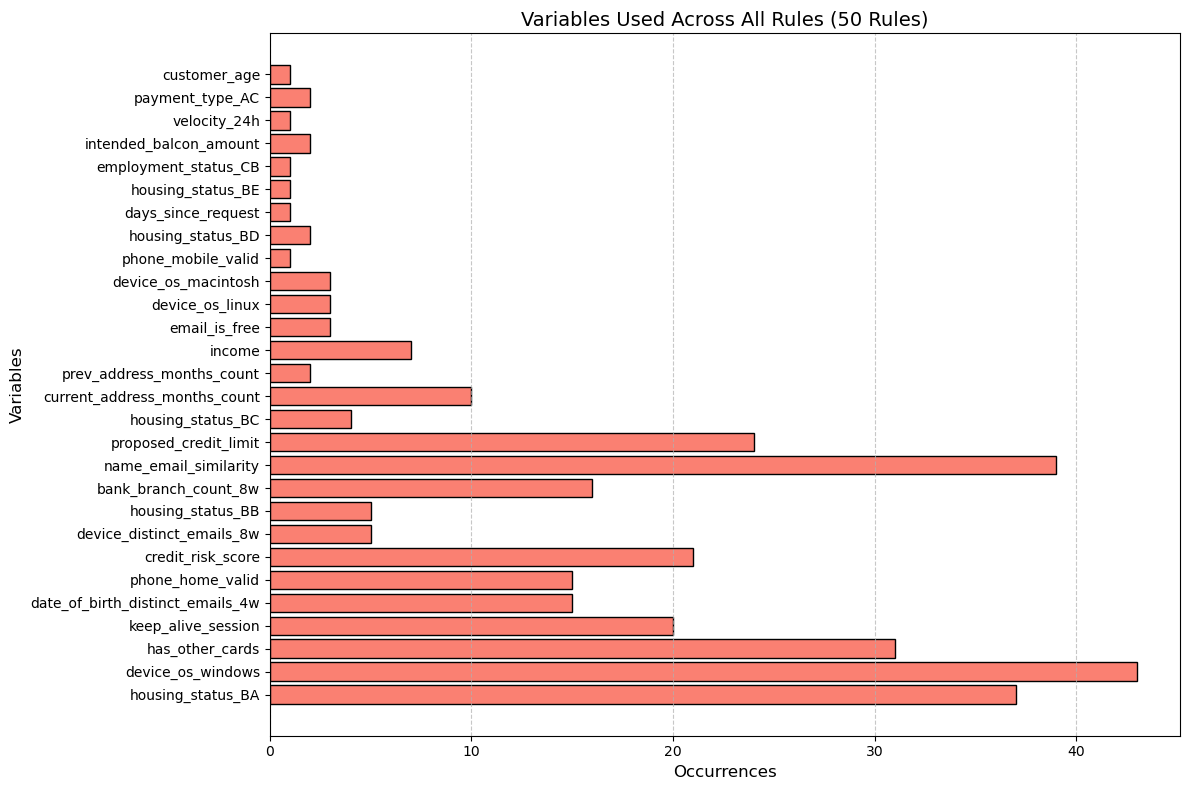

In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

# Get the 50 Rule Set Distributions by Length and Variables Used

# Function to analyze rules from Excel
def analyze_rules_excel(file_path):
    # Load the Excel file
    df = pd.read_excel(file_path)
    rules = df.iloc[:, 1].dropna().tolist()

    dimensions_count = Counter()
    variable_count = Counter()

    pattern = re.compile(r'([a-zA-Z][a-zA-Z0-9_]*)\s*(>=|<=|!=|>|<|==|=)\s*')

    for rule in rules:
        conditions = [c.strip() for c in re.split(r'\band\b|\bor\b', rule, flags=re.IGNORECASE) if c.strip()]
        dimensions_count[len(conditions)] += 1
        for match in pattern.finditer(rule):
            variable_count[match.group(1)] += 1

    return rules, dimensions_count, variable_count

file_path = 'data/Allrules.xlsx'
rule_data, dimensions_count, variable_count = analyze_rules_excel(file_path)

# Print summary
print("Rule distribution by dimensions:")
for dim, count in sorted(dimensions_count.items()):
    print(f"  {dim} dimensions: {count} rules")

print("\nVariables used across all rules:")
for var, count in sorted(variable_count.items(), key=lambda item: item[1], reverse=True):
    print(f"  {var}: {count} occurrences")

# Plotting the data
# 1. Rule distribution by dimensions
dimensions = list(dimensions_count.keys())
rule_counts = list(dimensions_count.values())

plt.figure(figsize=(8, 5))
plt.bar(dimensions, rule_counts, color='skyblue', edgecolor='black')
plt.xlabel('Number of Conditions', fontsize=24)
plt.ylabel('Number of Rules', fontsize=24)
plt.title('Rule Distribution by Length - 50 Rules', fontsize=22)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Variables used across all rules
variables = list(variable_count.keys())
occurrences = list(variable_count.values())

plt.figure(figsize=(12, 8))
plt.barh(variables, occurrences, color='salmon', edgecolor='black')
plt.xlabel('Occurrences', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.title('Variables Used Across All Rules (50 Rules)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

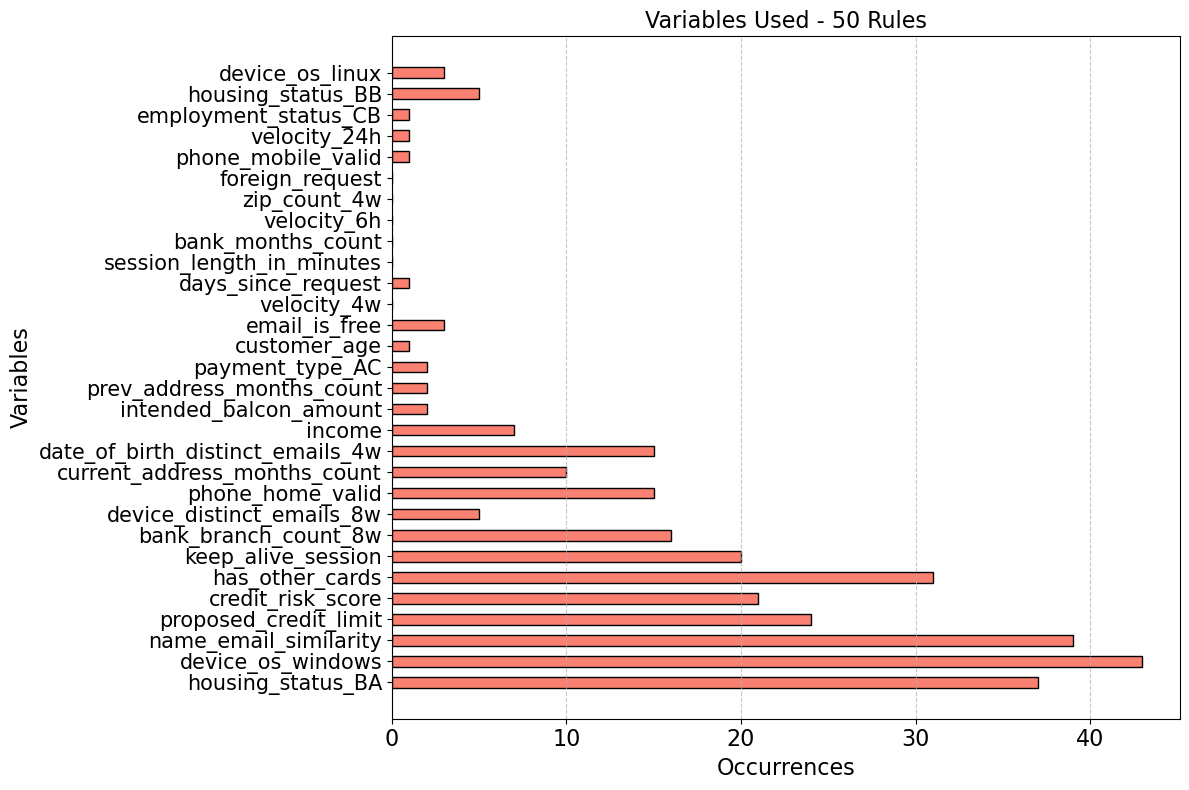

In [12]:
# Order the variables to be in the same sequence as in the Full Rule Set plot

# Variables and occurrences from the original dataset
reference_variables = [
    'housing_status_BA', 'device_os_windows', 'name_email_similarity', 
    'proposed_credit_limit', 'credit_risk_score', 'has_other_cards', 
    'keep_alive_session', 'bank_branch_count_8w', 'device_distinct_emails_8w',
    'phone_home_valid', 'current_address_months_count', 'date_of_birth_distinct_emails_4w',
    'income', 'intended_balcon_amount', 'prev_address_months_count',
    'payment_type_AC', 'customer_age', 'email_is_free', 'velocity_4w',
    'days_since_request', 'session_length_in_minutes', 'bank_months_count',
    'velocity_6h', 'zip_count_4w', 'foreign_request', 'phone_mobile_valid',
    'velocity_24h', 'employment_status_CB', 'housing_status_BB', 'device_os_linux'
]

# Create a dictionary for the new dataset occurrences
new_variable_occurrences = dict(variable_count)  # variable_count from the analysis

# Ensure all reference variables are included, even if missing from the new dataset
new_occurrences = [new_variable_occurrences.get(var, 0) for var in reference_variables]

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(reference_variables, new_occurrences, color='salmon', edgecolor='black', height=0.5)
plt.xlabel('Occurrences', fontsize=16)
plt.ylabel('Variables', fontsize=16)
plt.title('Variables Used - 50 Rules', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()